# Supplementary Notebook S3: KE and EKE Trends — Two-Satellite Product

Complementary analysis using the **two-satellite altimetry product** as a robustness check
against the all-satellite product used in the main analysis.
Produces the supplementary figure 'KE_EKE_trends_twosat' (trend-difference maps + timeseries/bars).

## Prerequisites

The two-satellite monthly half-power outputs must be generated first:

```bash
# Step 1 — compute two-sat monthly half-power fields
python scripts/run_all_two_sat.py
# output: outputs/monthly_half-power_points_two_sat/

# Step 2 — compute pixel-wise 2D trends from those fields
python scripts/ke_eke_2d_trends_two_sat.py
# output: outputs/trends/ke_eke_2d_trends_two_sat.nc
```

## Trend methodology
- **Trend estimator:** Theil-Sen robust median slope.
- **Significance test:** Mann-Kendall with autocorrelation correction (Yue & Wang, 2004).
- **Significance display:** stippled dots where p < 0.05.

In [1]:
import os
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.path as mpath
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import xarray as xr

# Resolve repo root whether notebook is run from notebooks/supplementary/ or repo root.
REPO_ROOT = Path(os.path.abspath(os.path.join(os.getcwd(), '..', '..')))
if not (REPO_ROOT / 'outputs' / 'trends').exists():
    REPO_ROOT = Path(os.path.abspath(os.path.join(os.getcwd(), '..')))
if not (REPO_ROOT / 'outputs' / 'trends').exists():
    REPO_ROOT = Path.cwd()

INPUT_2D_TRENDS_FILE = REPO_ROOT / 'outputs' / 'trends' / 'ke_eke_2d_trends_two_sat.nc'
PLOT_DIR = REPO_ROOT / 'outputs' / 'plots' / 'trends_split'
FIG_DIR = REPO_ROOT / 'figures' / 'supplementary'   # publication figures (tracked by git)
FIG_DIR.mkdir(parents=True, exist_ok=True)
PLOT_DIR.mkdir(parents=True, exist_ok=True)

STYLE = {
    'grid_alpha': 0.18,
    'grid_lw': 0.5,
    'title_size': 11,
    'tick_size': 9,
}

plt.rcParams.update({
    'font.family':       'sans-serif',
    'font.sans-serif':   ['Helvetica Neue', 'Helvetica', 'Arial', 'DejaVu Sans'],
    'font.size':         10,
    'axes.titlesize':    STYLE['title_size'],
    'axes.titleweight':  'bold',
    'figure.facecolor':  'white',
    'figure.dpi':        150,
    'savefig.dpi':       300,
    'savefig.bbox':      'tight',
    'savefig.facecolor': 'white',
})

if not INPUT_2D_TRENDS_FILE.exists():
    raise FileNotFoundError(
        f'Precomputed two-sat trend file not found: {INPUT_2D_TRENDS_FILE}\n'
        'Run:\n'
        '  python scripts/run_all_two_sat.py\n'
        '  python scripts/ke_eke_2d_trends_two_sat.py'
    )

print(f'Repo root : {REPO_ROOT}')
print(f'Input file: {INPUT_2D_TRENDS_FILE}')
print(f'Output dir: {PLOT_DIR}')

Repo root : repository
Input file: outputs/trends/ke_eke_2d_trends_two_sat.nc
Output dir: outputs/plots/trends_split


In [2]:
# Load precomputed 2D KE/EKE means and trend fields (two-satellite product)
with xr.open_dataset(INPUT_2D_TRENDS_FILE) as ds:
    lat_1d   = ds['latitude'].values.astype(float)
    lon_1d   = ds['longitude'].values.astype(float)
    ke_mean  = ds['ke_mean_cm2_s2'].values.astype(float)
    eke_mean = ds['eke_mean_cm2_s2'].values.astype(float)
    ke_slope  = ds['ke_slope_cm2_s2_yr'].values.astype(float)
    eke_slope = ds['eke_slope_cm2_s2_yr'].values.astype(float)
    ke_p  = ds['ke_pvalue'].values.astype(float)
    eke_p = ds['eke_pvalue'].values.astype(float)

# ADT for ACC contour overlay
SSH_ACC_SOUTH = -0.6
SSH_ACC_NORTH =  0.2
adt_ds  = xr.open_dataset(REPO_ROOT / 'outputs' / 'mean_adt.nc')
adt     = adt_ds['mean_adt'].squeeze()
lon_adt = adt['longitude'].values.astype(float)
lat_adt = adt['latitude'].values.astype(float)
if np.nanmax(lon_adt) > 180:
    lon_wrapped = ((lon_adt + 180.0) % 360.0) - 180.0
    ord_lon = np.argsort(lon_wrapped)
    lon_adt = lon_wrapped[ord_lon]
    adt = adt.isel(longitude=ord_lon)
adt_vals   = adt.values.astype(float)
acc_levels = [SSH_ACC_SOUTH, SSH_ACC_NORTH]

LON2D, LAT2D = np.meshgrid(lon_1d, lat_1d)
proj = ccrs.SouthPolarStereo()

# Sea-ice mask
PREPROC_ICE_FILE = REPO_ROOT / 'outputs' / 'sea_ice_mask.nc'
if not PREPROC_ICE_FILE.exists():
    raise FileNotFoundError(f'Sea-ice mask not found: {PREPROC_ICE_FILE}. Run Notebook 00 first.')
with xr.open_dataset(PREPROC_ICE_FILE) as ds_ice:
    ice_da = ds_ice['ice_mask']
    if 'latitude' in ice_da.coords and 'longitude' in ice_da.coords:
        ice_lon = ice_da['longitude'].values.astype(float)
        if np.nanmax(ice_lon) > 180 and np.nanmax(lon_1d) <= 180:
            ice_da = ice_da.assign_coords(
                longitude=((ice_da['longitude'] + 180.0) % 360.0) - 180.0
            ).sortby('longitude')
        ice_interp = ice_da.interp(latitude=lat_1d, longitude=lon_1d, method='nearest')
        ice_mask = ice_interp.values.astype(float) > 0.5
    else:
        ice_mask = ice_da.values.astype(float) > 0.5
ice_overlay = np.where(ice_mask, 1.0, np.nan)

# Masked arrays for plotting
ke_mean_plot   = np.where(ice_mask, np.nan, ke_mean)
eke_mean_plot  = np.where(ice_mask, np.nan, eke_mean)
ke_slope_plot  = np.where(ice_mask, np.nan, ke_slope)
eke_slope_plot = np.where(ice_mask, np.nan, eke_slope)

vmax_mean  = np.nanpercentile(np.r_[ke_mean[np.isfinite(ke_mean)], eke_mean[np.isfinite(eke_mean)]], 99)
trend_vals = np.r_[ke_slope_plot[np.isfinite(ke_slope_plot)], eke_slope_plot[np.isfinite(eke_slope_plot)]]
if trend_vals.size == 0:
    trend_vals = np.r_[ke_slope[np.isfinite(ke_slope)], eke_slope[np.isfinite(eke_slope)]]
vmax_trend = np.nanpercentile(np.abs(trend_vals), 97)

_STRIDE = 8  # ~1° spacing at 0.125° resolution


# ── Helper functions ────────────────────────────────────────────────────────
def map_ax_style(ax):
    ax.set_extent([-180, 180, -82, -35], crs=ccrs.PlateCarree())
    theta  = np.linspace(0, 2 * np.pi, 200)
    verts  = np.vstack([np.sin(theta), np.cos(theta)]).T
    circle = mpath.Path(verts * 0.5 + 0.5)
    ax.set_boundary(circle, transform=ax.transAxes)
    ax.add_feature(cfeature.LAND, facecolor='#000000', edgecolor='#555555', linewidth=0.2, zorder=2)
    ax.coastlines('50m', linewidth=0.45, color='#333333')
    gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True,
                      linewidth=0.30, color='#7A8288', alpha=0.45, linestyle=':')
    gl.xlocator = plt.FixedLocator(range(-180, 181, 60))
    gl.ylocator = plt.FixedLocator([-60, -40])
    gl.top_labels = gl.right_labels = False
    gl.xlabel_style = gl.ylabel_style = {'size': 7, 'color': '#4A4A4A'}
    ax.set_frame_on(False)



def add_acc_contours(ax):
    return ax.contour(lon_adt, lat_adt, adt_vals, levels=acc_levels,
                      colors=['#5f5f5f', '#2f2f2f'], linewidths=[0.6, 0.9],
                      alpha=0.65, transform=ccrs.PlateCarree(), zorder=2)



def add_sector_boundaries(ax):
    sector_lons = [20.0, 147.0, -70.0]  # 20E, 147E, 70W
    lats = np.linspace(-82, -35, 200)
    for lon in sector_lons:
        ax.plot(np.full_like(lats, lon), lats, color='#222222', lw=0.85,
                ls=(0, (5, 3)), transform=ccrs.PlateCarree(), zorder=5, alpha=0.75)



def add_ice_mask(ax):
    ax.contourf(lon_1d, lat_1d, ice_overlay, levels=[0.5, 1.5],
                colors=['#8EC5FF'], alpha=0.35, transform=ccrs.PlateCarree(), zorder=2)
    ax.contour(lon_1d, lat_1d, np.where(np.isfinite(ice_overlay), 1.0, np.nan),
               levels=[0.5], colors=['#595959'], linewidths=[0.35],
               alpha=0.5, transform=ccrs.PlateCarree(), zorder=4)



def add_stippling(ax, p_field, valid_mask, stride=_STRIDE):
    """Dots on pixels with p < 0.05 (Yue-Wang MK), subsampled at ~1° spacing."""
    sig = (p_field < 0.05) & valid_mask
    sub = np.zeros_like(sig)
    sub[::stride, ::stride] = True
    sub &= sig
    n = int(sub.sum())
    if n > 0:
        ax.scatter(LON2D[sub], LAT2D[sub], s=0.4, c='#1F2933', alpha=0.45,
                   transform=ccrs.PlateCarree(), zorder=3, rasterized=True, linewidths=0)
    return n

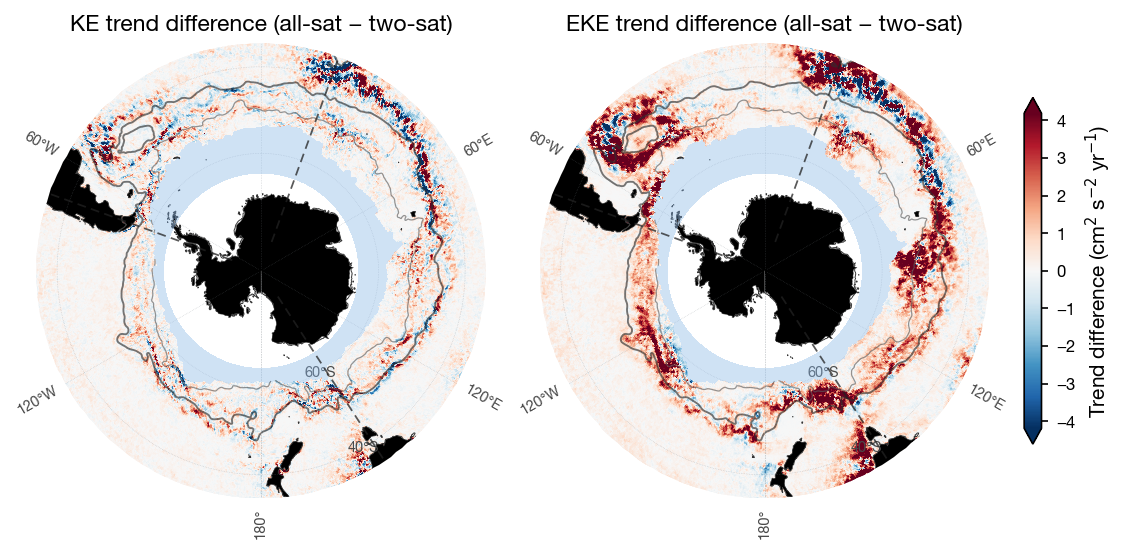

Saved: outputs/plots/trends_split/figD3_two_minus_all_sat_trend_difference.png


In [3]:
# Figure D3: Difference maps (two-sat minus all-sat)
ALL_2D_FILE = REPO_ROOT / 'outputs' / 'trends' / 'ke_eke_2d_trends.nc'
if not ALL_2D_FILE.exists():
    raise FileNotFoundError(f'All-satellite 2D trend file not found: {ALL_2D_FILE}')

with xr.open_dataset(ALL_2D_FILE) as ds_all:
    # align longitudes if needed to notebook grid (lon_1d)
    if np.nanmax(ds_all['longitude'].values) > 180 and np.nanmax(lon_1d) <= 180:
        ds_all = ds_all.assign_coords(longitude=((ds_all['longitude'] + 180.0) % 360.0) - 180.0).sortby('longitude')
    elif np.nanmax(ds_all['longitude'].values) <= 180 and np.nanmax(lon_1d) > 180:
        ds_all = ds_all.assign_coords(longitude=(ds_all['longitude'] % 360.0)).sortby('longitude')
    ds_all_interp = ds_all.interp(latitude=lat_1d, longitude=lon_1d, method='linear')
    ke_slope_all = ds_all_interp['ke_slope_cm2_s2_yr'].values.astype(float)
    eke_slope_all = ds_all_interp['eke_slope_cm2_s2_yr'].values.astype(float)

# compute differences (all_sat - two_sat)
ke_diff = ke_slope_all - ke_slope
eke_diff = eke_slope_all - eke_slope

ke_diff_plot = np.where(ice_mask, np.nan, ke_diff)
eke_diff_plot = np.where(ice_mask, np.nan, eke_diff)

diff_vals = np.r_[ke_diff_plot[np.isfinite(ke_diff_plot)], eke_diff_plot[np.isfinite(eke_diff_plot)]]
vmax_diff = np.nanpercentile(np.abs(diff_vals), 97) if diff_vals.size else np.nanmax(np.abs(diff_vals))
vmax_diff = float(vmax_diff) if np.isfinite(vmax_diff) else 0.0

fig = plt.figure(figsize=(10, 5))
gs = fig.add_gridspec(1, 2, wspace=0.12)
ax1 = fig.add_subplot(gs[0, 0], projection=proj)
ax2 = fig.add_subplot(gs[0, 1], projection=proj)
for ax in (ax1, ax2):
    map_ax_style(ax)

trend_cmap = plt.get_cmap('RdBu_r').copy()
trend_cmap.set_bad('#F3F2EF')

im1 = ax1.pcolormesh(LON2D, LAT2D, ke_diff_plot, transform=ccrs.PlateCarree(),
                     cmap=trend_cmap, vmin=-vmax_diff, vmax=vmax_diff, shading='auto', rasterized=True)
add_acc_contours(ax1)
add_ice_mask(ax1)
add_sector_boundaries(ax1)
ax1.set_title('KE trend difference (all-sat − two-sat)')

im2 = ax2.pcolormesh(LON2D, LAT2D, eke_diff_plot, transform=ccrs.PlateCarree(),
                     cmap=trend_cmap, vmin=-vmax_diff, vmax=vmax_diff, shading='auto', rasterized=True)
add_acc_contours(ax2)
add_ice_mask(ax2)
add_sector_boundaries(ax2)
ax2.set_title('EKE trend difference (all-sat − two-sat)')

cb = fig.colorbar(im1, ax=[ax1, ax2], shrink=0.6, pad=0.03, orientation='vertical', extend='both')
cb.set_label(r'Trend difference (cm$^2$ s$^{-2}$ yr$^{-1}$)')
cb.ax.tick_params(labelsize=8)

# Supplementary figure 'KE_EKE_trends_twosat', top panels (trend difference maps)
out_fig3 = FIG_DIR / 'KE_EKE_trends_twosat_maps.png'
fig.savefig(out_fig3, dpi=400, bbox_inches='tight')
plt.show()
print(f'Saved: {out_fig3}')

## Figure D2: Two-Satellite KE/EKE Time Series and Regional Trend Bars

This section reproduces the manuscript-style summary panels for the two-satellite product:

- Whole Southern Ocean KE/EKE time series with rolling means and Theil-Sen trend lines.
- Regional/ACC trend bar chart with 95% CI and Mann-Kendall significance stars.

Outputs:
- `outputs/trends/energy_field_timeseries_two_sat.csv`
- `outputs/trends/trend_bars_two_sat.csv`
- `outputs/plots/trends_split/figD2_ke_eke_timeseries_bars_two_sat.png`

Saved two-sat time series: outputs/trends/energy_field_timeseries_two_sat.csv
Records: 1500
Saved trend bars table: outputs/trends/trend_bars_two_sat.csv


/var/folders/ms/8hpcnj2j01zd81g0v_5l2ttw0000gn/T/ipykernel_14520/1862507416.py:497: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


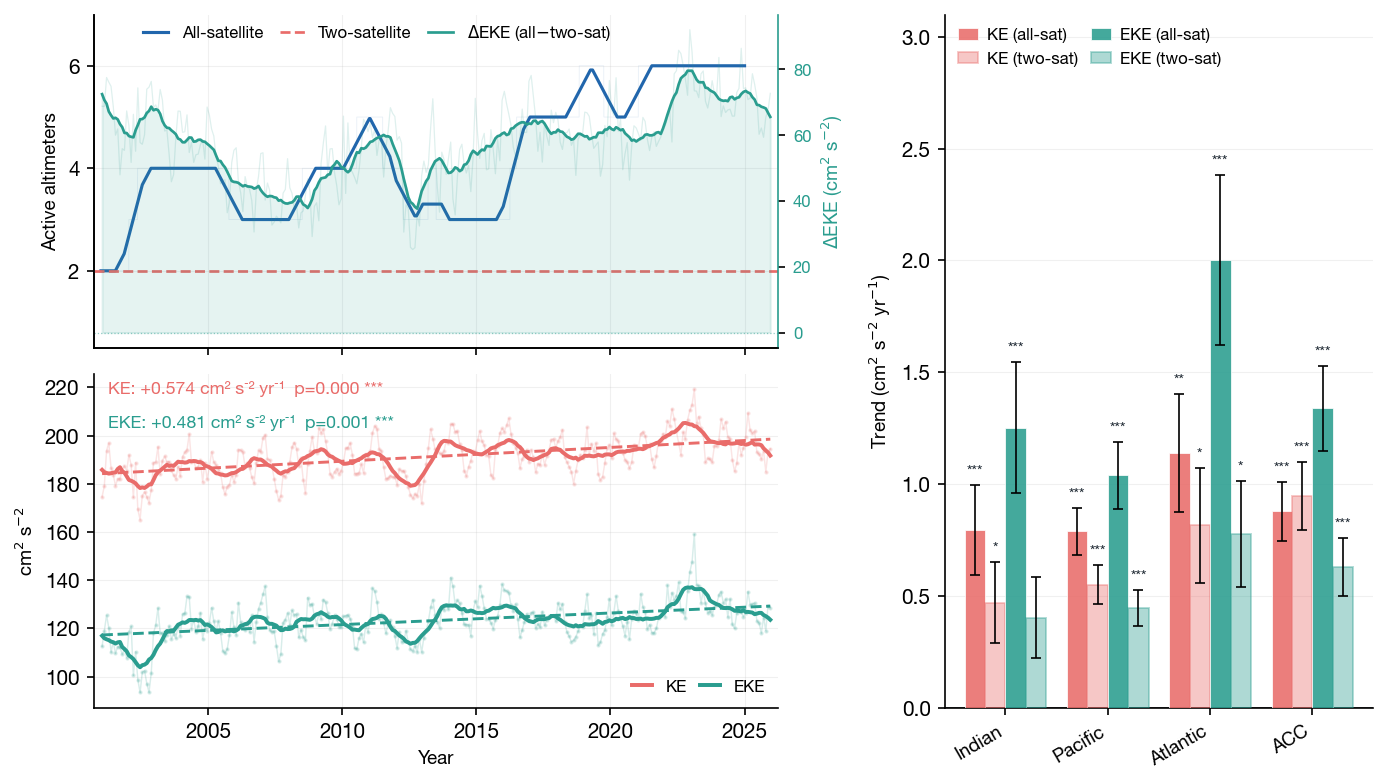

Saved: outputs/plots/trends_split/figD2_ke_eke_timeseries_bars_two_sat.png


In [4]:
import pandas as pd
from scipy import stats

INPUT_HP_TWO_SAT = REPO_ROOT / 'outputs' / 'monthly_half-power_points_two_sat'
ALL_SAT_TS_FILE  = REPO_ROOT / 'outputs' / 'trends' / 'energy_field_timeseries.csv'
OUT_TS_TWO_SAT   = REPO_ROOT / 'outputs' / 'trends' / 'energy_field_timeseries_two_sat.csv'
OUT_TREND_BARS   = REPO_ROOT / 'outputs' / 'trends' / 'trend_bars_two_sat.csv'

REGION_ORDER = ['Indian', 'Pacific', 'Atlantic', 'ACC']
STYLE_TS = {
    'raw_alpha': 0.18,
    'raw_lw': 0.7,
    'smooth_lw': 1.9,
    'trend_lw': 1.4,
    'grid_alpha': 0.18,
    'grid_lw': 0.5,
    'tick_size': 9,
    'annot_size': 9,
    'ke': '#e96c6a',
    'eke': '#2A9D8F',
}

def stars(p):
    if not np.isfinite(p):
        return ''
    if p < 0.001:
        return '***'
    if p < 0.01:
        return '**'
    if p < 0.05:
        return '*'
    return ''

def theil_sen_with_ci(x, y):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    m = np.isfinite(x) & np.isfinite(y)
    if m.sum() < 3:
        return {'slope': np.nan, 'intercept': np.nan, 'lo': np.nan, 'hi': np.nan, 'se': np.nan}
    res = stats.theilslopes(y[m], x[m], alpha=0.95)
    slope = float(res.slope)
    intercept = float(res.intercept)
    lo = float(res.low_slope)
    hi = float(res.high_slope)
    se = (hi - lo) / (2 * 1.96) if np.isfinite(lo) and np.isfinite(hi) else np.nan
    return {'slope': slope, 'intercept': intercept, 'lo': lo, 'hi': hi, 'se': se}

def _mk_s_var(y):
    n = len(y)
    s = 0
    for i in range(n - 1):
        s += np.sign(y[i + 1:] - y[i]).sum()
    _, counts = np.unique(y, return_counts=True)
    tie_term = np.sum(counts * (counts - 1) * (2 * counts + 5))
    var_s = (n * (n - 1) * (2 * n + 5) - tie_term) / 18.0
    return s, var_s

def mann_kendall_yue_wang(y, alpha=0.05, max_lag=12):
    y = np.asarray(y, dtype=float)
    y = y[np.isfinite(y)]
    n = len(y)
    if n < 5:
        return {'tau': np.nan, 'p': np.nan, 'n_eff': np.nan}

    s, var_s = _mk_s_var(y)
    tau = s / (0.5 * n * (n - 1))

    x = np.arange(n, dtype=float)
    ts = theil_sen_with_ci(x, y)
    if np.isfinite(ts['slope']) and np.isfinite(ts['intercept']):
        y_for_ac = y - (ts['slope'] * x + ts['intercept'])
    else:
        y_for_ac = y - np.nanmean(y)

    ranks = stats.rankdata(y_for_ac)
    r = ranks - np.mean(ranks)
    denom = np.sum(r**2)
    if denom <= 0:
        return {'tau': tau, 'p': np.nan, 'n_eff': np.nan}

    max_lag = min(max_lag, n - 2)
    sig_rhos = []
    for k in range(1, max_lag + 1):
        num = np.sum(r[:-k] * r[k:])
        rho_k = num / denom
        crit = stats.norm.ppf(1 - alpha / 2) / np.sqrt(n)
        if np.abs(rho_k) > crit:
            sig_rhos.append((k, rho_k))

    if len(sig_rhos) == 0:
        n_eff = n
    else:
        corr_sum = np.sum([(1 - k / n) * rho for k, rho in sig_rhos])
        n_eff = n / (1 + 2 * corr_sum)
        n_eff = np.clip(n_eff, 2, n)

    var_s_adj = var_s * (n / n_eff)
    if s > 0:
        z = (s - 1) / np.sqrt(var_s_adj)
    elif s < 0:
        z = (s + 1) / np.sqrt(var_s_adj)
    else:
        z = 0.0
    p = 2 * stats.norm.sf(abs(z))
    return {'tau': float(tau), 'p': float(p), 'n_eff': float(n_eff)}

def sector_masks(lon_1d):
    lon360 = np.mod(lon_1d, 360.0)
    m_atl = (lon360 >= 290.0) | (lon360 < 20.0)
    m_ind = (lon360 >= 20.0) & (lon360 < 147.0)
    m_pac = (lon360 >= 147.0) & (lon360 < 290.0)
    return {'Atlantic': m_atl, 'Indian': m_ind, 'Pacific': m_pac}

monthly_files = sorted(INPUT_HP_TWO_SAT.glob('*/*.nc'))
if len(monthly_files) == 0:
    raise FileNotFoundError(f'No monthly two-satellite files found under: {INPUT_HP_TWO_SAT}')

with xr.open_dataset(monthly_files[0]) as ds0:
    lat_hp = ds0['latitude'].values.astype(float)
    lon_hp = ds0['longitude'].values.astype(float)
lat_w = np.cos(np.deg2rad(lat_hp))[:, None]
lon_masks = sector_masks(lon_hp)

with xr.open_dataset(REPO_ROOT / 'outputs' / 'mean_adt.nc') as ds_adt_mean:
    adt_mean = ds_adt_mean['mean_adt'].squeeze()
    adt_lon = adt_mean['longitude'].values.astype(float)
    if np.nanmax(adt_lon) > 180 and np.nanmax(lon_hp) <= 180:
        adt_mean = adt_mean.assign_coords(
            longitude=((adt_mean['longitude'] + 180.0) % 360.0) - 180.0
        ).sortby('longitude')
    elif np.nanmax(adt_lon) <= 180 and np.nanmax(lon_hp) > 180:
        adt_mean = adt_mean.assign_coords(
            longitude=(adt_mean['longitude'] % 360.0)
        ).sortby('longitude')
    adt_on_hp = adt_mean.interp(latitude=lat_hp, longitude=lon_hp, method='linear')

ACC_SOUTH = -0.6
ACC_NORTH = 0.2
acc_mask = np.isfinite(adt_on_hp.values) & (adt_on_hp.values >= ACC_SOUTH) & (adt_on_hp.values <= ACC_NORTH)

def weighted_mean(arr, mask2d, w2d):
    valid = np.isfinite(arr) & mask2d
    if not np.any(valid):
        return np.nan
    ww = np.where(valid, w2d, 0.0)
    den = np.nansum(ww)
    if den <= 0:
        return np.nan
    return float(np.nansum(arr * ww) / den)

rows = []
for f in monthly_files:
    year = int(f.parent.name)
    month = int(f.stem)
    dec_year = year + (month - 0.5) / 12.0

    with xr.open_dataset(f) as ds_m:
        ke = ds_m['ke'].values.astype(float)
        eke = ds_m['eke'].values.astype(float)

    if ke.shape != acc_mask.shape:
        raise ValueError(f'Shape mismatch for {f.name}: {ke.shape} vs {acc_mask.shape}')

    w2d = np.broadcast_to(lat_w, ke.shape)

    # Whole Southern Ocean
    whole_mask = np.isfinite(ke) | np.isfinite(eke)
    rows.append({
        'year': year,
        'month': month,
        'decimal_year': dec_year,
        'region': 'Whole SO',
        'mean_ke': weighted_mean(ke, whole_mask, w2d),
        'mean_eke': weighted_mean(eke, whole_mask, w2d),
    })

    # Indian / Pacific / Atlantic sectors
    for region in ['Indian', 'Pacific', 'Atlantic']:
        reg2d = np.broadcast_to(lon_masks[region][None, :], ke.shape)
        rows.append({
            'year': year,
            'month': month,
            'decimal_year': dec_year,
            'region': region,
            'mean_ke': weighted_mean(ke, reg2d, w2d),
            'mean_eke': weighted_mean(eke, reg2d, w2d),
        })

    # ACC from ADT contour mask
    rows.append({
        'year': year,
        'month': month,
        'decimal_year': dec_year,
        'region': 'ACC',
        'mean_ke': weighted_mean(ke, acc_mask, w2d),
        'mean_eke': weighted_mean(eke, acc_mask, w2d),
    })

energy_two_sat = pd.DataFrame(rows).sort_values(['region', 'year', 'month']).reset_index(drop=True)
OUT_TS_TWO_SAT.parent.mkdir(parents=True, exist_ok=True)
energy_two_sat.to_csv(OUT_TS_TWO_SAT, index=False)
print(f'Saved two-sat time series: {OUT_TS_TWO_SAT}')
print(f'Records: {len(energy_two_sat)}')

# ── Two-sat: Whole SO series and regional trend bars ─────────────────────────
so_grp = energy_two_sat[energy_two_sat['region'] == 'Whole SO'].sort_values('decimal_year').copy()
x = so_grp['decimal_year'].values.astype(float)
y_ke  = so_grp['mean_ke'].values.astype(float)  * 1e4
y_eke = so_grp['mean_eke'].values.astype(float) * 1e4

trend_rows = []
for region in REGION_ORDER:
    grp = energy_two_sat[energy_two_sat['region'] == region].sort_values('decimal_year')
    x_reg = grp['decimal_year'].values.astype(float)
    for var, label in [('mean_ke', 'KE'), ('mean_eke', 'EKE')]:
        y_reg = grp[var].values.astype(float) * 1e4
        ts_res = theil_sen_with_ci(x_reg, y_reg)
        mk_res = mann_kendall_yue_wang(y_reg)
        ci95 = 1.96 * ts_res['se'] if np.isfinite(ts_res['se']) else np.nan
        trend_rows.append({
            'region': region,
            'variable': label,
            'slope': ts_res['slope'],
            'ci95': ci95,
            'mk_p': mk_res['p'],
        })

trend_reg_df = pd.DataFrame(trend_rows)
trend_reg_df.to_csv(OUT_TREND_BARS, index=False)
print(f'Saved trend bars table: {OUT_TREND_BARS}')

ke_reg_df  = trend_reg_df[trend_reg_df['variable'] == 'KE'].set_index('region').reindex(REGION_ORDER)
eke_reg_df = trend_reg_df[trend_reg_df['variable'] == 'EKE'].set_index('region').reindex(REGION_ORDER)

# ── All-satellite: regional trend bars (from precomputed CSV) ─────────────────
if not ALL_SAT_TS_FILE.exists():
    raise FileNotFoundError(
        f'All-sat time series not found: {ALL_SAT_TS_FILE}\n'
        'Run notebook 03a first to generate energy_field_timeseries.csv'
    )
energy_all_sat = pd.read_csv(ALL_SAT_TS_FILE)
if 'decimal_year' not in energy_all_sat.columns:
    energy_all_sat['decimal_year'] = energy_all_sat['year'] + (energy_all_sat['month'] - 0.5) / 12.0

all_sat_rows = []
for region in REGION_ORDER:
    grp = energy_all_sat[energy_all_sat['region'] == region].sort_values('decimal_year')
    x_reg = grp['decimal_year'].values.astype(float)
    for var, label in [('mean_ke', 'KE'), ('mean_eke', 'EKE')]:
        y_reg = grp[var].values.astype(float) * 1e4
        ts_res = theil_sen_with_ci(x_reg, y_reg)
        mk_res = mann_kendall_yue_wang(y_reg)
        ci95 = 1.96 * ts_res['se'] if np.isfinite(ts_res['se']) else np.nan
        all_sat_rows.append({
            'region': region,
            'variable': label,
            'slope': ts_res['slope'],
            'ci95': ci95,
            'mk_p': mk_res['p'],
        })

all_sat_df  = pd.DataFrame(all_sat_rows)
ke_all_df   = all_sat_df[all_sat_df['variable'] == 'KE'].set_index('region').reindex(REGION_ORDER)
eke_all_df  = all_sat_df[all_sat_df['variable'] == 'EKE'].set_index('region').reindex(REGION_ORDER)

# ── ACC EKE difference time series (all-sat minus two-sat) ───────────────────
_acc_all = (
    energy_all_sat[energy_all_sat['region'] == 'ACC']
    .sort_values('decimal_year')[['year', 'month', 'decimal_year', 'mean_eke']]
    .rename(columns={'mean_eke': 'eke_all'})
)
_acc_2sat = (
    energy_two_sat[energy_two_sat['region'] == 'ACC']
    .sort_values('decimal_year')[['year', 'month', 'decimal_year', 'mean_eke']]
    .rename(columns={'mean_eke': 'eke_2sat'})
)
_diff_df = pd.merge(_acc_all, _acc_2sat, on=['year', 'month', 'decimal_year']).dropna()
x_diff   = _diff_df['decimal_year'].values.astype(float)
y_diff   = (_diff_df['eke_all'].values - _diff_df['eke_2sat'].values).astype(float) * 1e4
rm_diff  = pd.Series(y_diff).rolling(12, center=True, min_periods=6).mean().values

# ── Daily active altimeter count from known DUACS operational periods ─────────
# Source: AVISO DUACS DT2021 documentation. A 365-day running mean smooths the
# transitions as missions are added or retired. True per-day along-track
# observation counts would require the L3 product; the daily active-mission count
# shown here is the standard proxy used in altimetry constellation figures.
_DUACS_MISSIONS = [
    # (mission,        start,          end)
    ('T/P',         '2001-01-01', '2005-10-08'),  # active at study start
    ('ERS-2',       '2001-01-01', '2011-07-04'),  # active at study start
    ('Jason-1',     '2002-01-15', '2013-07-01'),
    ('Envisat',     '2002-05-14', '2012-04-08'),
    ('Jason-2',     '2008-07-04', '2019-10-01'),
    ('Cryosat-2',   '2010-07-16', '2030-12-31'),
    ('SARAL',       '2013-03-14', '2030-12-31'),
    ('Jason-3',     '2016-04-01', '2030-12-31'),
    ('Sentinel-3A', '2016-07-01', '2030-12-31'),
    ('Sentinel-3B', '2018-11-01', '2030-12-31'),
    ('Sentinel-6A', '2021-01-15', '2030-12-31'),
]

_dr  = pd.date_range('2001-01-01', '2024-12-31', freq='D')
_cnt = pd.Series(0, index=_dr)
for _, _s, _e in _DUACS_MISSIONS:
    _m = (_cnt.index >= pd.Timestamp(_s)) & (_cnt.index <= pd.Timestamp(_e))
    _cnt[_m] += 1

x_nobs_all  = (_dr.year + (_dr.dayofyear - 1) / 365.25).values.astype(float)
y_nobs_all  = _cnt.values.astype(float)
rm_nobs_all = pd.Series(y_nobs_all).rolling(365, center=True, min_periods=180).mean().values

# ── DUACS all-satellite constellation approximate count history ───────────────
# Based on AVISO DUACS DT2021 documentation.  Counts are approximate (±1-3 months);
# each step corresponds to a confirmed mission integration.
_SAT_STEPS = np.array([
    [2001.00, 2],   # Study start: T/P + ERS-2
    [2002.10, 3],   # + Jason-1 (launched Dec 2001, operational ~Feb 2002)
    [2008.55, 4],   # + Jason-2 (launched Jun 2008)
    [2010.30, 5],   # + Cryosat-2 (launched Apr 2010)
    [2011.55, 4],   # - ERS-2 retired (Jul 2011) / - Envisat (Apr 2012)  net -1
    [2013.20, 5],   # + SARAL/AltiKa (launched Feb 2013)
    [2016.30, 7],   # + Jason-3 (op. Apr 2016) + Sentinel-3A (op. mid-2016)
    [2018.90, 8],   # + Sentinel-3B (launched Apr 2018, op. ~Nov 2018)
    [2021.10, 9],   # + Sentinel-6A/MF (launched Nov 2020, op. ~Feb 2021)
    [2024.92, 9],
])
_SAT_LABELS = {
    2002.10: 'Jason-1',
    2008.55: 'Jason-2',
    2010.30: 'Cryosat-2',
    2011.55: '\u2212ERS-2/Envisat',
    2013.20: 'SARAL',
    2016.30: 'Jason-3 + S-3A',
    2018.90: 'S-3B',
    2021.10: 'S-6A',
}


# ── FIGURE D2 ────────────────────────────────────────────────────────────────
# Layout: two columns.
#   Col 0: (a) satellite count + EKE diff  /  (b) KE/EKE time series
#   Col 1: (c) regional trend bars (full height)
import matplotlib.gridspec as gridspec
from matplotlib.lines import Line2D as _L2D

fig = plt.figure(figsize=(11, 6))
gs_main = gridspec.GridSpec(2, 2,
                             figure=fig,
                             height_ratios=[1.0, 1.0],
                             width_ratios=[1.6, 1.0],
                             hspace=0.08,
                             wspace=0.30, 
                    )
ax_sat = fig.add_subplot(gs_main[0, 0])
ax_ts  = fig.add_subplot(gs_main[1, 0], sharex=ax_sat)
ax_bar = fig.add_subplot(gs_main[:, 1])   # full-height right column

# ── (a) Altimeter constellation ──────────────────────────────────────────────
ax_sat.plot(x_nobs_all, y_nobs_all,  color='#2166AC', alpha=0.10, lw=0.4, zorder=1)
ax_sat.plot(x_nobs_all, rm_nobs_all, color='#2166AC', lw=1.5, zorder=2,
            label='All-satellite')
ax_sat.axhline(2, color='#e96c6a', lw=1.3, ls='--', zorder=3,
               label='Two-satellite')
ax_sat.set_xlim(x.min() - 0.3, x.max() + 0.3)
ax_sat.set_ylim(0.5, np.nanmax(rm_nobs_all[np.isfinite(rm_nobs_all)]) + 1.0)
ax_sat.yaxis.set_major_locator(plt.MaxNLocator(integer=True, nbins=5))
ax_sat.set_ylabel('Active altimeters', fontsize=9)
ax_sat.grid(alpha=STYLE_TS['grid_alpha'], lw=STYLE_TS['grid_lw'])
ax_sat.tick_params(labelbottom=False)
ax_sat.spines['top'].set_visible(False)
ax_sat.spines['right'].set_visible(False)


# Twin axis: ACC EKE difference
ax_diff = ax_sat.twinx()
ax_diff.plot(x_diff, y_diff,  color=STYLE_TS['eke'], alpha=0.15, lw=0.6, zorder=1)
ax_diff.plot(x_diff, rm_diff, color=STYLE_TS['eke'], lw=1.3, zorder=2,
             label=r'$\Delta$EKE (all$-$two-sat)')
ax_diff.fill_between(x_diff, 0, rm_diff, where=np.isfinite(rm_diff),
                     color=STYLE_TS['eke'], alpha=0.12, zorder=1)
ax_diff.axhline(0, color=STYLE_TS['eke'], lw=0.6, ls=':', alpha=0.5)
ax_diff.set_ylabel(r'$\Delta$EKE (cm$^2$ s$^{-2}$)', fontsize=9, color=STYLE_TS['eke'])
ax_diff.tick_params(axis='y', labelcolor=STYLE_TS['eke'], labelsize=8)
ax_diff.spines['top'].set_visible(False)
ax_diff.spines['right'].set_color(STYLE_TS['eke'])
h1, l1 = ax_sat.get_legend_handles_labels()
h2, l2 = ax_diff.get_legend_handles_labels()
ax_sat.legend(h1 + h2, l1 + l2, loc='upper left', fontsize=8, frameon=False,
              ncol=3, borderpad=0, columnspacing=1.0, handlelength=1.5,
              bbox_to_anchor=(0.06, 1.0))

# ── (b) Two-satellite Whole SO KE/EKE time series ────────────────────────────
ax_ts.plot(x, y_ke,  color=STYLE_TS['ke'],  alpha=STYLE_TS['raw_alpha'],
           marker='.', ms=2, lw=STYLE_TS['raw_lw'])
ax_ts.plot(x, y_eke, color=STYLE_TS['eke'], alpha=STYLE_TS['raw_alpha'],
           marker='.', ms=2, lw=STYLE_TS['raw_lw'])
if len(so_grp) >= 12:
    rm_ke  = pd.Series(y_ke).rolling(12, center=True, min_periods=6).mean()
    rm_eke = pd.Series(y_eke).rolling(12, center=True, min_periods=6).mean()
    ax_ts.plot(x, rm_ke,  color=STYLE_TS['ke'],  lw=STYLE_TS['smooth_lw'])
    ax_ts.plot(x, rm_eke, color=STYLE_TS['eke'], lw=STYLE_TS['smooth_lw'])

res_ke  = theil_sen_with_ci(x, y_ke)
mk_ke   = mann_kendall_yue_wang(y_ke)
if np.isfinite(res_ke['slope']):
    xf = np.array([np.nanmin(x), np.nanmax(x)])
    ax_ts.plot(xf, res_ke['intercept'] + res_ke['slope'] * xf,
               color=STYLE_TS['ke'], ls='--', lw=STYLE_TS['trend_lw'])

res_eke = theil_sen_with_ci(x, y_eke)
mk_eke  = mann_kendall_yue_wang(y_eke)
if np.isfinite(res_eke['slope']):
    xf = np.array([np.nanmin(x), np.nanmax(x)])
    ax_ts.plot(xf, res_eke['intercept'] + res_eke['slope'] * xf,
               color=STYLE_TS['eke'], ls='--', lw=STYLE_TS['trend_lw'])

ax_ts.text(0.02, 0.98,
           f"KE: {res_ke['slope']:+.3f} cm² s⁻² yr⁻¹  "
           f"p={mk_ke['p']:.3f} {stars(mk_ke['p'])}",
           transform=ax_ts.transAxes, va='top', ha='left',
           fontsize=8.5, color=STYLE_TS['ke'])
ax_ts.text(0.02, 0.88,
           f"EKE: {res_eke['slope']:+.3f} cm² s⁻² yr⁻¹  "
           f"p={mk_eke['p']:.3f} {stars(mk_eke['p'])}",
           transform=ax_ts.transAxes, va='top', ha='left',
           fontsize=8.5, color=STYLE_TS['eke'])
ax_ts.set_xlabel('Year', fontsize=9)
ax_ts.set_ylabel(r'cm$^2$ s$^{-2}$', fontsize=9)
ax_ts.grid(alpha=STYLE_TS['grid_alpha'], lw=STYLE_TS['grid_lw'])
ax_ts.spines['top'].set_visible(False)
ax_ts.spines['right'].set_visible(False)
ax_ts.legend(
    handles=[
        _L2D([0], [0], color=STYLE_TS['ke'],  lw=STYLE_TS['smooth_lw']),
        _L2D([0], [0], color=STYLE_TS['eke'], lw=STYLE_TS['smooth_lw']),
    ],
    labels=['KE', 'EKE'],
    loc='lower right', ncol=2, fontsize=8, frameon=False,
    borderpad=0.3, columnspacing=0.8, handlelength=1.2,
)

# ── (c) Regional trend bars: all-sat vs two-sat (full-height right column) ────
xpos = np.arange(len(REGION_ORDER))
w = 0.20
bar_configs = [
    ('ke_all',   ke_all_df,  STYLE_TS['ke'],  0.88, 'white',         'KE (all-sat)'),
    ('ke_2sat',  ke_reg_df,  STYLE_TS['ke'],  0.38, STYLE_TS['ke'],  'KE (two-sat)'),
    ('eke_all',  eke_all_df, STYLE_TS['eke'], 0.88, 'white',         'EKE (all-sat)'),
    ('eke_2sat', eke_reg_df, STYLE_TS['eke'], 0.38, STYLE_TS['eke'], 'EKE (two-sat)'),
]
offsets = [-1.5 * w, -0.5 * w, 0.5 * w, 1.5 * w]

all_slopes = []
for (key, df, color, alpha, edgec, lbl), offset in zip(bar_configs, offsets):
    slopes = df['slope'].values
    errs   = np.where(np.isfinite(df['ci95'].values), df['ci95'].values, 0.0)
    ax_bar.bar(
        xpos + offset,
        slopes,
        yerr=errs,
        width=w,
        color=color,
        alpha=alpha,
        edgecolor=edgec,
        linewidth=0.9 if edgec != 'white' else 0.4,
        error_kw={'lw': 0.8, 'capsize': 2.5, 'capthick': 0.8, 'ecolor': "k"},
        zorder=3,
        label=lbl,
    )
    all_slopes.extend(slopes[np.isfinite(slopes)].tolist())

yr = max(np.nanmax(np.abs(all_slopes)) if all_slopes else 1e-6, 1e-6)
for (key, df, color, alpha, edgec, _), offset in zip(bar_configs, offsets):
    for i, region in enumerate(REGION_ORDER):
        s  = df.loc[region, 'slope']
        e  = df.loc[region, 'ci95'] if np.isfinite(df.loc[region, 'ci95']) else 0.0
        p  = df.loc[region, 'mk_p']
        st = stars(p)
        if st and np.isfinite(s):
            ytxt = s + e + 0.015 * yr if s >= 0 else s - e - 0.015 * yr
            ax_bar.text(xpos[i] + offset, ytxt, st,
                        ha='center', va='bottom' if s >= 0 else 'top',
                        fontsize=7.5, fontweight='semibold', color='#1F2933')

ax_bar.axhline(0, color='#495057', lw=0.9, zorder=2)
ax_bar.set_ylim(0,3.1)
ax_bar.set_xticks(xpos)
ax_bar.set_xticklabels(REGION_ORDER, rotation=30, ha='right', fontsize=9)
ax_bar.set_ylabel(r'Trend (cm$^2$ s$^{-2}$ yr$^{-1}$)', fontsize=9)
ax_bar.grid(axis='y', alpha=STYLE_TS['grid_alpha'], lw=STYLE_TS['grid_lw'])
ax_bar.spines['top'].set_visible(False)
ax_bar.spines['right'].set_visible(False)
ax_bar.legend(frameon=False, fontsize=8, loc='upper left', ncol=2,
              borderpad=0.3, columnspacing=0.8, handlelength=1.2, handletextpad=0.5)


fig.tight_layout()
# Supplementary figure 'KE_EKE_trends_twosat', bottom panels (timeseries + bars)
out_fig2 = FIG_DIR / 'KE_EKE_trends_twosat_timeseries_bars.png'
fig.savefig(out_fig2, dpi=400, bbox_inches='tight')
plt.show()
print(f'Saved: {out_fig2}')
